<a href="https://colab.research.google.com/github/ipavlopoulos/greek-letter-vision/blob/main/cnn_embeddings_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data

In [ ]:
#@title Load the data
%%capture
!gdown 1CMcTsxSzz6vzvrq_OIwOJFtowI3KHPOa
!gdown 1JnaVPaqDA60zpT7gkq6VtIPf8nlBGi87
!unzip Timeline20250531.zip

In [22]:
#@title Load the model weights
!wget https://github.com/ipavlopoulos/greek-letter-vision/raw/refs/heads/main/best_cnn_letter_model.pth

--2025-08-29 23:18:52--  https://github.com/ipavlopoulos/greek-letter-vision/raw/refs/heads/main/best_cnn_letter_model.pth
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/ipavlopoulos/greek-letter-vision/refs/heads/main/best_cnn_letter_model.pth [following]
--2025-08-29 23:18:52--  https://raw.githubusercontent.com/ipavlopoulos/greek-letter-vision/refs/heads/main/best_cnn_letter_model.pth
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17203749 (16M) [application/octet-stream]
Saving to: ‘best_cnn_letter_model.pth.2’

best_cnn_letter_mod 100%[===================>]  16.41M  89.4MB/s    in 0.2s   

In [23]:
#@title Get the metadata
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from sklearn.decomposition import PCA
import numpy as np
from PIL import Image
import cv2
import pandas as pd

image_folder = 'Timeline20250531/cliplets/'
image_files = [os.path.join(image_folder, f) for f in os.listdir(image_folder) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Adding metadata
filenames = os.listdir('Timeline20250531/cliplets/')
data = pd.DataFrame({'filename': filenames})
data['letter'] = data.filename.apply(lambda x: x.split('_')[0])
data['TM'] = data.filename.apply(lambda x: int(x.split('_')[1]))
data['number'] = data.filename.apply(lambda x: x.split('_')[2].split('.')[0])
metadata = pd.read_csv('metadata.csv')
data['year'] = data.TM.apply(lambda x: metadata.loc[metadata['TM'] == x]['Year ante quem'].values[0])
data['region'] = data.TM.apply(lambda x: metadata.loc[metadata['TM'] == x]['Production Nome (supposed)'].values[0])

In [24]:
#@title Dataset development
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torchvision.transforms as transforms
import torch
import numpy as np
import cv2
import random

class RandomLacunae(object):
    """
    Apply lacunae-like erasures to simulate missing text regions (irregular blobs).
    """
    def __init__(self, num_lacunae=(1, 4), size_range=(0.02, 0.15), p=0.5, v=0.5):
        """
        Args:
            num_lacunae (tuple): min/max number of lacunae per image
            size_range (tuple): relative size range (as fraction of image area)
            p (float): probability of applying the augmentation
        """
        self.num_lacunae = num_lacunae
        self.size_range = size_range
        self.p = p
        self.v = v

    def __call__(self, img):
        if random.random() > self.p:
            return img

        img_np = np.array(img).copy()
        h, w = img_np.shape[:2]

        for _ in range(random.randint(*self.num_lacunae)):
            # Random size relative to image
            lacuna_area = random.uniform(*self.size_range) * h * w
            lacuna_w = int(np.sqrt(lacuna_area) * random.uniform(0.5, 1.5))
            lacuna_h = int(np.sqrt(lacuna_area) * random.uniform(0.5, 1.5))

            # Random center
            x = random.randint(0, w - 1)
            y = random.randint(0, h - 1)

            # Create irregular blob mask using cv2 ellipse + random contour distortion
            mask = np.zeros((h, w), dtype=np.uint8)
            cv2.ellipse(mask, (x, y), (lacuna_w//2, lacuna_h//2),
                        angle=random.randint(0, 180),
                        startAngle=0, endAngle=360,
                        color=1, thickness=-1)

            # Optionally: erode/dilate with noise to add irregularity
            if random.random() < 0.7:
                kernel_size = random.choice([3,5,7])
                kernel = np.ones((kernel_size,kernel_size), np.uint8)
                if random.random() < 0.5:
                    mask = cv2.erode(mask, kernel, iterations=1)
                else:
                    mask = cv2.dilate(mask, kernel, iterations=1)

            # Apply lacuna (set pixels to background = white/255)
            img_np[mask == 1] = 255 * self.v  # assuming grayscale / white parchment

        return torch.tensor(img_np) if isinstance(img, torch.Tensor) else img_np

# Preprocess images for 2D CNN (resize and normalize, no flattening yet)
def preprocess_image_2d(image_path, size=(64, 64), otsu=False):
    img = Image.open(image_path).convert('L')  # Grayscale
    img_np = np.array(img)

    if otsu:
      _, img_np = cv2.threshold(img_np, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
      img_np = 255 - img_np

    # Resize to standard size
    img_resized = cv2.resize(img_np, size, interpolation=cv2.INTER_AREA)

    # Normalize pixel values to [0, 1]
    img_normalized = img_resized.astype(np.float32) / 255.0

    return img_normalized  # Return as 2D numpy array


# Preprocess all images for 2D CNN
image_data_2d = []

for img_file in image_files:
    try:
        processed_img_2d = preprocess_image_2d(img_file)
        image_data_2d.append(processed_img_2d)
    except Exception as e:
        print(f"Error processing image {img_file} for 2D CNN: {e}")

image_data_2d = np.array(image_data_2d)

# The original image data (image_data_2d) for the 2D CNN
train_data_split = data[data['letter'] != 'Unknown'].copy()
unk_data_split = data[data['letter'] == 'Unknown'].copy()

# Get the indices for splitting
train_indices_2d = train_data_split.index.tolist()
unk_indices_2d = unk_data_split.index.tolist()

# Encode the letter labels into integers
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(train_data_split['letter'])

# Split the indices for train/val/test
train_indices_2d, test_indices_2d, y_train_encoded_2d, y_test_encoded_2d = train_test_split(
    train_indices_2d,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

train_indices_2d, val_indices_2d, y_train_encoded_2d, y_val_encoded_2d = train_test_split(
    train_indices_2d,
    y_train_encoded_2d,
    test_size=0.1,
    random_state=42,
    stratify=y_train_encoded_2d
)


# Select image data and labels using the indices
X_train_2d = image_data_2d[train_indices_2d]
y_train_2d = y_train_encoded_2d

X_val_2d = image_data_2d[val_indices_2d]
y_val_2d = y_val_encoded_2d

X_test_2d = image_data_2d[test_indices_2d]
y_test_2d = y_test_encoded_2d

X_unk_2d = image_data_2d[unk_indices_2d]

# --- Data Augmentation for 2D Images ---
# Define image transformations including data augmentation
data_transform = transforms.Compose([
    transforms.RandomRotation(10),      # Rotate by up to 10 degrees
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # Translate horizontally and vertically
    transforms.RandomResizedCrop(size=(64, 64), scale=(0.8, 1.0)), # Random crop and resize
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Adjust brightness and contrast
    RandomLacunae(num_lacunae=(0,2), size_range=(0.02,0.12), p=0.5, v=1),
    transforms.ToTensor(),             # Convert to PyTorch Tensor (adds channel dimension)
    #transforms.RandomErasing(p=0.5, value=0), # erase parts (lacunae)
    transforms.Normalize((0.5,), (0.5,)), # Normalize (assuming grayscale images)
])

# Transformation for validation and test sets (no augmentation)
test_transform = transforms.Compose([
    # Removed redundant transforms.ToPILImage()
    transforms.ToTensor(), # Adds channel dimension
    transforms.Normalize((0.5,), (0.5,))
])

# Create custom PyTorch dataset for 2D data with augmentation
class ImageDatasetAugmented(Dataset):
    def __init__(self, X, y=None, transform=None):
        self.X = X # Expecting numpy array of images
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        # Convert numpy array (H, W) to PIL Image (H, W) expected by transforms
        # Convert back to uint8 for PIL, as transforms expect uint8 or float in [0, 1]
        # Also ensure it's in the correct mode ('L' for grayscale)
        image = Image.fromarray((image * 255).astype(np.uint8))

        if self.transform:
            # Apply the transforms
            image = self.transform(image)

        # The transform pipeline includes ToTensor() and normalization, so 'image' is now a tensor
        if self.y is not None:
            return image, self.y[idx]
        else:
            return image


# Create DataLoaders for 2D data with augmentation
batch_size = 16
train_loader_2d_aug = DataLoader(ImageDatasetAugmented(X_train_2d, y_train_2d, transform=data_transform), batch_size=batch_size, shuffle=True)
val_loader_2d = DataLoader(ImageDatasetAugmented(X_val_2d, y_val_2d, transform=test_transform), batch_size=batch_size)
test_loader_2d = DataLoader(ImageDatasetAugmented(X_test_2d, y_test_2d, transform=test_transform), batch_size=batch_size)
unk_loader_2d = DataLoader(ImageDatasetAugmented(X_unk_2d, transform=test_transform), batch_size=batch_size) # Assuming unknown inference needs standard processing

In [25]:
#@title Train data - not augmented

class SimpleDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx]
        # Convert numpy array (H, W) to PIL Image (H, W) expected by transforms
        # Convert back to uint8 for PIL, as transforms expect uint8 or float in [0, 1]
        # Also ensure it's in the correct mode ('L' for grayscale)
        image = Image.fromarray((image * 255).astype(np.uint8))

        # Apply only the test_transform (ToTensor and Normalize)
        if test_transform:
             image = test_transform(image)

        if self.y is not None:
            return image, self.y[idx]
        else:
            return image

train_dataset_no_aug = SimpleDataset(image_data_2d[train_indices_2d], y_train_encoded_2d)
test_dataset_no_aug = SimpleDataset(image_data_2d[test_indices_2d], y_test_encoded_2d)
train_loader_no_aug = DataLoader(train_dataset_no_aug, batch_size=batch_size)
test_loader_no_aug = DataLoader(test_dataset_no_aug, batch_size=batch_size)

In [26]:
#@title Source (algorithm)
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torch
import torch.nn as nn
import torch.optim as optim
import cv2
import numpy as np
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn.functional as F

class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss as in Khosla et al. (2020)
    https://arxiv.org/abs/2004.11362
    """
    def __init__(self, temperature=0.07):
        super(SupConLoss, self).__init__()
        self.temperature = temperature

    def forward(self, features, labels):
        """
        features: tensor of shape [batch_size, embed_dim]
        labels: tensor of shape [batch_size]
        """
        device = features.device
        features = F.normalize(features, dim=1)

        batch_size = features.shape[0]

        # Compute similarity matrix
        similarity_matrix = torch.matmul(features, features.T) / self.temperature

        # Mask: remove self-comparisons
        mask = torch.eye(batch_size, dtype=torch.bool).to(device)
        similarity_matrix = similarity_matrix.masked_fill(mask, -1e9)

        # Positive mask: same label
        labels = labels.contiguous().view(-1, 1)
        positive_mask = torch.eq(labels, labels.T).to(device)

        # For each sample, compute log-softmax
        log_prob = F.log_softmax(similarity_matrix, dim=1)

        # Only keep positives
        mean_log_prob_pos = (positive_mask * log_prob).sum(1) / positive_mask.sum(1).clamp(min=1)

        # Final loss
        loss = -mean_log_prob_pos.mean()
        return loss

class CNN2D(nn.Module):
    def __init__(self, num_classes, image_size=(64, 64)):
        super(CNN2D, self).__init__()
        self.image_size = image_size
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        # Calculate the size of the flattened features after conv and pooling
        with torch.no_grad():
            dummy_input = torch.randn(1, 1, image_size[0], image_size[1]) # (batch_size, channels, height, width)
            dummy_output = self.pool3(self.relu(self.conv3(self.pool2(self.relu(self.conv2(self.pool1(self.relu(self.conv1(dummy_input)))))))))
            flattened_size = dummy_output.shape[1] * dummy_output.shape[2] * dummy_output.shape[3]

        self.fc1 = nn.Linear(flattened_size, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # Remove the unsqueeze(1) call as ToTensor() already adds the channel dimension
        # x = x.unsqueeze(1) # Add a channel dimension (batch_size, 1, height, width)
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1) # Flatten the tensor
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

    def get_embeddings(self, x):
        """Return embeddings before the final classification layer"""
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return x   # <-- embeddings (size = 512)

class SimilarityWeightedSupConLoss(nn.Module):
    """Supervised Contrastive Loss with class-similarity-weighted negatives."""
    def __init__(self, S_class, temperature=0.07, lambda_weight=1.0, eps=1e-8):
        super().__init__()
        self.register_buffer("S_class", S_class.float())
        self.temperature = temperature
        self.lambda_weight = lambda_weight
        self.eps = eps
        C = S_class.shape[0]
        mask_offdiag = (~torch.eye(C, dtype=torch.bool, device=S_class.device))
        self.S_bar = S_class[mask_offdiag].mean().clamp(min=eps)

    def forward(self, features, labels):
        z = F.normalize(features, dim=1)
        sim = torch.matmul(z, z.t()) / self.temperature
        B = z.size(0)
        eye = torch.eye(B, device=features.device, dtype=torch.bool)
        sim = sim.masked_fill(eye, -1e9)
        y = labels.view(-1, 1)
        pos_mask = (y == y.t()) & (~eye)
        S_pairs = self.S_class[labels][:, labels]
        w = 1.0 + self.lambda_weight * (S_pairs / self.S_bar)
        neg_mask = (~pos_mask) & (~eye)
        w = w * neg_mask.float() + pos_mask.float() + eye.float()
        exp_sim = torch.exp(sim) * (1.0 - eye.float())
        denom = (w * exp_sim).sum(dim=1, keepdim=True).clamp(min=self.eps)
        log_prob = sim - torch.log(denom)
        pos_count = pos_mask.sum(dim=1).clamp(min=1)
        mean_log_prob_pos = (pos_mask.float() * log_prob).sum(dim=1) / pos_count
        loss = -mean_log_prob_pos.mean()
        return loss

def compute_prototypes(embeddings, labels, num_classes):
    protos = []
    for c in range(num_classes):
        v = embeddings[labels == c].mean(axis=0)
        v = v / (np.linalg.norm(v) + 1e-12)
        protos.append(v)
    return np.stack(protos)  # [C, D]

def build_S_from_prototypes(model, loader, device, num_classes):
    model.eval()
    Z, Y = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            z = model.get_embeddings(x).cpu().numpy()
            Z.append(z); Y.append(y.numpy())
    Z = np.vstack(Z); Y = np.concatenate(Y)
    P = compute_prototypes(Z, Y, num_classes)           # [C, D]
    # cosine similarity in [−1, 1] → clamp to [0,1]
    S = P @ P.T
    S = np.clip(S, 0.0, 1.0)
    np.fill_diagonal(S, 0.0)
    return torch.tensor(S, dtype=torch.float32, device=device)


def get_tta_embeddings(model, x, y, n_views, tta_transform, device):
    """Apply TTA safely to a batch."""
    B = x.size(0)
    x_aug_list = []
    for img in x:  # iterate over batch
        aug_imgs = [tta_transform(img.cpu()) for _ in range(n_views)]
        x_aug_list.extend(aug_imgs)
    x_aug = torch.stack(x_aug_list).to(device)
    y_aug = y.repeat(n_views)
    emb = model.get_embeddings(x_aug)
    return emb, y_aug

def train_cnn2d(model, train_loader, val_loader, device,
                num_classes, num_epochs=100, lam_scl_weight=0.1,
                n_views=2, tta_transform=None, use_swscl=True,
                use_tta=True, update_S_every=3, patience=10,
                save_path='best_cnn_letter_model.pth',
                learning_rate=0.001,
                similarity_matrix_fn=None,
                ema_alpha=0.0):
    """
    Train CNN2D with optional SW-SCL and TTA embeddings.
    """
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    ce_loss_fn = nn.CrossEntropyLoss()
    best_val_loss = float('inf')
    epochs_no_improve = 0
    train_losses, val_losses, val_accuracies = [], [], []

    if similarity_matrix_fn is None:
        similarity_matrix_fn = build_S_from_prototypes

    S_matrix = None
    swscl_loss_fn = None

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        # --- Update similarity matrix dynamically ---
        if use_swscl and (epoch % update_S_every == 0 or S_matrix is None):
            new_S = similarity_matrix_fn(model, train_loader, device, num_classes)
            if S_matrix is None or ema_alpha == 0.0:
                S_matrix = new_S
            else:
                S_matrix = ema_alpha * S_matrix + (1 - ema_alpha) * new_S
            swscl_loss_fn = SimilarityWeightedSupConLoss(S_matrix, temperature=0.07, lambda_weight=1.0)

        for x_orig, y in train_loader:
            x_orig, y = x_orig.to(device), y.to(device)

            # --- CE Loss ---
            logits = model(x_orig)
            ce_loss = ce_loss_fn(logits, y)

            # --- SW-SCL Loss ---
            if use_swscl:
                if use_tta and tta_transform is not None and n_views > 1:
                    emb, y_aug = get_tta_embeddings(model, x_orig, y, n_views, tta_transform, device)
                else:
                    emb, y_aug = model.get_embeddings(x_orig), y
                swscl_loss = swscl_loss_fn(emb, y_aug)
            else:
                swscl_loss = 0.0

            loss = ce_loss + lam_scl_weight * swscl_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x_orig.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = ce_loss_fn(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        val_accuracy = correct / total
        val_losses.append(epoch_val_loss)
        val_accuracies.append(val_accuracy)

        print(f'Epoch [{epoch+1}/{num_epochs}] '
              f'Train Loss: {epoch_loss:.4f}, '
              f'Val Loss: {epoch_val_loss:.4f}, '
              f'Val Accuracy: {val_accuracy:.4f}')

        # --- Early stopping ---
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), save_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'Early stopping triggered after {epoch+1} epochs.')
                break

    return train_losses, val_losses, val_accuracies

def evaluate(model, test_loader, device, label_encoder):
    model.eval()
    correct = 0
    total = 0
    pred, gold = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            pred.extend(predicted.cpu().numpy())
            gold.extend(labels.cpu().numpy())

    # Inverse transform the encoded predicted and true labels to get original letter names
    pred = label_encoder.inverse_transform(pred)
    gold = label_encoder.inverse_transform(gold)

    # Display classification report
    print(classification_report(gold, pred, zero_division=0))

    # Display confusion matrix
    cm_2d = confusion_matrix(gold, pred, labels=label_encoder.classes_)

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_2d, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.savefig('cnn2d_aug_confusion_matrix.pdf', dpi=300, format='PDF')
    plt.show()

# TTA/augmentation for embeddings
tta_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1,0.1)),
    transforms.RandomResizedCrop(size=(64,64), scale=(0.8,1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2)
])

def custom_similarity_matrix(model, loader, device, num_classes):
    # e.g., compute S differently or add class-specific weighting
    S = build_S_from_prototypes(model, loader, device, num_classes)
    return S * 0.5  # example: scale similarity

In [27]:
#@title Load the model
model = CNN2D(num_classes=len(label_encoder.classes_), image_size=(64, 64))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.load_state_dict(torch.load('best_cnn_letter_model.pth', map_location=torch.device(device)))
#evaluate(model, test_loader_2d, device, label_encoder)

<All keys matched successfully>

In [21]:
#@title Extract the embeddings
def extract_embeddings(model, dataloader, device):
    model.eval()
    embeddings = []
    labels = []

    with torch.no_grad():
        for batch in dataloader:
            if isinstance(batch, (list, tuple)):
                images, targets = batch
                labels.extend(targets.numpy())
            else:
                images = batch
                targets = None

            images = images.to(device)
            emb = model.get_embeddings(images)  # (batch_size, 512)
            embeddings.append(emb.cpu().numpy())

    embeddings = np.vstack(embeddings)
    if labels:
        labels = np.array(labels)
        return embeddings, labels
    else:
        return embeddings

# Extract embeddings
train_embeddings, train_labels = extract_embeddings(model, train_loader_2d_aug, device)
train_embeddings_no_aug, train_labels_no_aug = extract_embeddings(model, train_loader_no_aug, device)
test_embeddings, test_labels = extract_embeddings(model, test_loader_2d, device)

# KMEANS

In [ ]:
#@title LefCNN embeddings
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score, normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import numpy as np

num_classes = len(np.unique(train_labels_no_aug))

# 2. Run KMeans (unsupervised)
kmeans = KMeans(n_clusters=num_classes, random_state=42, n_init=20)
kmeans.fit(train_embeddings_no_aug)

# 3. Assign each cluster a majority-vote label
from scipy.stats import mode

cluster_labels = {}
for c in range(num_classes):
    indices = np.where(kmeans.labels_ == c)[0]
    if len(indices) > 0:
        majority_label = mode(train_labels[indices], keepdims=False).mode
        cluster_labels[c] = majority_label

# 4. Predict test set
test_clusters = kmeans.predict(test_embeddings)
y_pred_kmeans = np.array([cluster_labels[c] for c in test_clusters])

# 5. Evaluate
print("\nEvaluation on LefCNN features:")
#print(classification_report(test_labels, y_pred_kmeans, target_names=label_encoder.classes_, zero_division=0))
print(f"Normalized Mutual Information (NMI): {normalized_mutual_info_score(test_labels, y_pred_kmeans):.3f}")
print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(test_labels, y_pred_kmeans):.3f}")
print(f"Homogeneity: {homogeneity_score(test_labels, y_pred_kmeans):.3f}")
print(f"Completeness: {completeness_score(test_labels, y_pred_kmeans):.3f}")
print(f"V-measure: {v_measure_score(test_labels, y_pred_kmeans):.3f}")


Evaluation on LefCNN features:
Normalized Mutual Information (NMI): 0.428
Adjusted Rand Index (ARI): 0.189
Homogeneity: 0.367
Completeness: 0.512
V-measure: 0.428


In [ ]:
#@title Otsu+PCA 500D binarized
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score, normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import numpy as np
from scipy.stats import mode

# Preprocess all images with Otsu
image_data_ot = np.array([preprocess_image_2d(img_file, otsu=True) for img_file in image_files])

# 1. Get train and test Otsu-thresholded, flattened, raw (pixel) data
train_pixel_data = image_data_ot[train_indices_2d].reshape(image_data_ot[train_indices_2d].shape[0], -1)
test_pixel_data = image_data_ot[test_indices_2d].reshape(image_data_ot[test_indices_2d].shape[0], -1)
train_labels_pixel = y_train_encoded_2d
test_labels_pixel = y_test_encoded_2d
num_classes = len(np.unique(train_labels_pixel))

# 2. Apply PCA
n_components = 500
pca = PCA(n_components=n_components, random_state=42)

# Fit PCA on training data and transform both
train_pca_features = pca.fit_transform(train_pixel_data)
test_pca_features = pca.transform(test_pixel_data)

print(f"Explained variance ratio by {n_components} components: {pca.explained_variance_ratio_.sum():.4f}")

# 3. Run KMeans (unsupervised) on PCA features
kmeans_pca = KMeans(n_clusters=num_classes, random_state=42, n_init=20)
kmeans_pca.fit(train_pca_features)

cluster_labels = {}
for c in range(num_classes):
    indices = np.where(kmeans_pca.labels_ == c)[0]
    if len(indices) > 0:
        majority_label = mode(train_labels_pixel[indices], keepdims=False).mode
        cluster_labels[c] = majority_label

# 4. Predict test set
test_clusters_pca = kmeans_pca.predict(test_pca_features)
y_pred_kmeans_pca = np.array([cluster_labels[c] for c in test_clusters_pca])


# 5. Evaluate
print("\nEvaluation on PCA features:")
#print(f"KMeans-based classifier accuracy: {accuracy_score(test_labels_pixel, y_pred_kmeans_pca)}")
#print(classification_report(test_labels_pixel, y_pred_kmeans_pca, target_names=label_encoder.classes_, zero_division=0))
print(f"Normalized Mutual Information (NMI): {normalized_mutual_info_score(test_labels_pixel, y_pred_kmeans_pca)}")
print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(test_labels_pixel, y_pred_kmeans_pca)}")
print(f"Homogeneity: {homogeneity_score(test_labels_pixel, y_pred_kmeans_pca)}")
print(f"Completeness: {completeness_score(test_labels_pixel, y_pred_kmeans_pca)}")
print(f"V-measure: {v_measure_score(test_labels_pixel, y_pred_kmeans_pca)}")


Evaluation on PCA features:
Normalized Mutual Information (NMI): 0.31740662834309663
Adjusted Rand Index (ARI): 0.15039317791576282
Homogeneity: 0.30298876142418646
Completeness: 0.33326521496347067
V-measure: 0.31740662834309663


In [ ]:
#@title ResNet18 embeddings
import torchvision.models as models
import torch.nn as nn
import torch
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score, normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
from scipy.stats import mode
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms

# --- Code from Feature Extraction using a Pre-trained Model (Cell EUzYXFlgDznn) ---
# Load a pre-trained model (e.g., ResNet18)
pretrained_model = models.resnet18(weights='IMAGENET1K_V1')

# Remove the last layer (the fully connected layer)
num_ftrs = pretrained_model.fc.in_features
pretrained_model.fc = nn.Identity() # Replace the last layer with an identity layer

# Move the model to the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pretrained_model.to(device)
pretrained_model.eval() # Set the model to evaluation mode

def extract_pretrained_embeddings(model, dataloader, device):
    model.eval()
    embeddings = []
    labels = []

    with torch.no_grad():
        for batch in dataloader:
            if isinstance(batch, (list, tuple)):
                images, targets = batch
                labels.extend(targets.numpy())
            else:
                images = batch
                targets = None

            # Pre-trained models often expect 3 channel images (RGB)
            # Our images are grayscale (1 channel), so we'll replicate the channel
            images = images.repeat(1, 3, 1, 1) # Repeat the single channel 3 times
            images = images.to(device)

            emb = model(images)  # (batch_size, feature_dim)
            embeddings.append(emb.cpu().numpy())

    embeddings = np.vstack(embeddings)
    if labels:
        labels = np.array(labels)
        return embeddings, labels
    else:
        return embeddings


# Extract embeddings using the pre-trained model
print("Extracting features using pre-trained ResNet18...")
train_pretrained_embeddings, train_pretrained_labels = extract_pretrained_embeddings(pretrained_model, train_loader_no_aug, device)
test_pretrained_embeddings, test_pretrained_labels = extract_pretrained_embeddings(pretrained_model, test_loader_2d, device)

# --- End of Code from Feature Extraction Cell ---

print("\nApplying KMeans on pre-trained features:")
num_classes = len(np.unique(train_pretrained_labels))

# 2. Run KMeans (unsupervised) on pre-trained embeddings
kmeans_pretrained = KMeans(n_clusters=num_classes, random_state=42, n_init=20)
kmeans_pretrained.fit(train_pretrained_embeddings)

# 3. Assign each cluster a majority-vote label
cluster_labels_pretrained = {}
for c in range(num_classes):
    indices = np.where(kmeans_pretrained.labels_ == c)[0]
    if len(indices) > 0:
        majority_label = mode(train_pretrained_labels[indices], keepdims=False).mode
        cluster_labels_pretrained[c] = majority_label

# 4. Predict test set
test_clusters_pretrained = kmeans_pretrained.predict(test_pretrained_embeddings)
y_pred_kmeans_pretrained = np.array([cluster_labels_pretrained[c] for c in test_clusters_pretrained])

# 5. Evaluate
print("Evaluation on Pre-trained CNN embeddings (using KMeans):")
#print(f"KMeans-based classifier accuracy: {accuracy_score(test_pretrained_labels, y_pred_kmeans_pretrained)}")
#print(classification_report(test_pretrained_labels, y_pred_kmeans_pretrained, target_names=label_encoder.classes_, zero_division=0))
print(f"Normalized Mutual Information (NMI): {normalized_mutual_info_score(test_pretrained_labels, y_pred_kmeans_pretrained)}")
print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(test_pretrained_labels, y_pred_kmeans_pretrained)}")
print(f"Homogeneity: {homogeneity_score(test_pretrained_labels, y_pred_kmeans_pretrained)}")
print(f"Completeness: {completeness_score(test_pretrained_labels, y_pred_kmeans_pretrained)}")
print(f"V-measure: {v_measure_score(test_pretrained_labels, y_pred_kmeans_pretrained)}")

Extracting features using pre-trained ResNet18...

Applying KMeans on pre-trained features:
Evaluation on Pre-trained CNN embeddings (using KMeans):
Normalized Mutual Information (NMI): 0.06748935821781141
Adjusted Rand Index (ARI): 0.01029362586572541
Homogeneity: 0.06132300469448119
Completeness: 0.07503447259653508
V-measure: 0.06748935821781141


# Spectral Clustering

In [ ]:
#@title LefCNN Embeddings

from sklearn.cluster import SpectralClustering
from sklearn.metrics import classification_report, accuracy_score, normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import numpy as np
from scipy.stats import mode

sc_cnn = SpectralClustering(n_clusters=num_classes,
                            assign_labels='discretize', # or 'kmeans'
                            random_state=42,
                            affinity='nearest_neighbors', # Use nearest neighbors graph
                            n_neighbors=min(10, test_embeddings.shape[0] - 1)) # Number of neighbors

test_clusters_sc_e = sc_cnn.fit_predict(test_embeddings)

cluster_labels_sc_e = {}
for c in range(num_classes): # Iterate up to n_clusters_spectral
    indices = np.where(test_clusters_sc_e == c)[0]
    if len(indices) > 0:
        majority_label = mode(test_labels[indices], keepdims=False).mode
        cluster_labels_sc_e[c] = majority_label

# Handle potential clusters that didn't get a majority label (e.g., empty clusters if discretize is used)
# Assign a default value (-1 or a placeholder) for clusters not in the map
y_pred_spectral = np.array([cluster_labels_sc_e.get(c, -1) for c in test_clusters_sc_e])

# Filter out samples that couldn't be mapped if necessary (e.g., if -1 is used)
# For evaluation metrics that require all samples, you might need a different strategy
# or ensure that all predicted clusters are mapped.
# Assuming all predicted clusters are intended to be mapped if possible:

# Convert back to original labels for classification report
# Filter out -1 predictions if any (though with discretize, all should be assigned a cluster 0 to n_clusters-1)
valid_indices = y_pred_spectral != -1
y_pred_spectral_original = label_encoder.inverse_transform(y_pred_spectral[valid_indices])
test_labels_original = label_encoder.inverse_transform(test_labels_pixel[valid_indices])

# 5. Evaluate
print("\nEvaluation on CNN embeddings (before augmentation) using Spectral Clustering:")
if len(valid_indices) > 0:
    #print(f"Spectral Clustering-based classifier accuracy (mapped on test set): {accuracy_score(test_labels_original, y_pred_spectral_original)}")
    #print(classification_report(test_labels_original, y_pred_spectral_original, target_names=label_encoder.classes_, zero_division=0))
    # NMI, ARI, etc. are ideally computed between true labels and cluster assignments directly
    print(f"Normalized Mutual Information (NMI): {normalized_mutual_info_score(test_labels, test_clusters_sc_e)}")
    print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(test_labels, test_clusters_sc_e)}")
    print(f"Homogeneity: {homogeneity_score(test_labels, test_clusters_sc_e)}")
    print(f"Completeness: {completeness_score(test_labels, test_clusters_sc_e)}")
    print(f"V-measure: {v_measure_score(test_labels, test_clusters_sc_e)}")
else:
    print("No valid predictions to evaluate.")


Evaluation on CNN embeddings (before augmentation) using Spectral Clustering:
Normalized Mutual Information (NMI): 0.6310821666448804
Adjusted Rand Index (ARI): 0.4421922216818613
Homogeneity: 0.6314897152351612
Completeness: 0.6306751437598461
V-measure: 0.6310821666448804


In [ ]:
#@title Otsu-PCA features

print("Applying Spectral Clustering on Otsu-PCA features...")

# We will cluster the test set independently for evaluation.
sc = SpectralClustering(n_clusters=num_classes,
                        assign_labels='discretize', # or 'kmeans'
                        random_state=42,
                        affinity='nearest_neighbors', # Use nearest neighbors graph
                        n_neighbors=10) # Number of neighbors

test_clusters_sc = sc.fit_predict(test_pca_features)

# Map test clusters to true labels using the *test set's* true labels
cluster_labels_sc = {}
for c in range(num_classes):
    indices = np.where(test_clusters_sc == c)[0]
    if len(indices) > 0:
        majority_label = mode(test_labels[indices], keepdims=False).mode
        cluster_labels_sc[c] = majority_label

# Assign majority-vote labels to the clustered test data
y_pred_sc = np.array([cluster_labels_sc.get(c, -1) for c in test_clusters_sc])

# Convert back to original labels for classification report
y_pred_sc = label_encoder.inverse_transform(y_pred_sc)
#test_labels_ot_pixel_original = label_encoder.inverse_transform(test_labels)

# 5. Evaluate
print("\nEvaluation on Otsu-thresholded flattened pixel features using Spectral Clustering:")
#print(f"Spectral Clustering-based classifier accuracy (mapped on test set): {accuracy_score(test_labels_ot_pixel_original, y_pred_sc)}")
#print(classification_report(test_labels_ot_pixel_original, y_pred_sc, target_names=label_encoder.classes_, zero_division=0))
print(f"Normalized Mutual Information (NMI): {normalized_mutual_info_score(test_labels_pixel, test_clusters_sc)}") # NMI compares true labels to cluster assignments directly
print(f"Adjusted Rand Index (ARI): {adjusted_rand_score(test_labels_pixel, test_clusters_sc)}") # ARI compares true labels to cluster assignments directly
print(f"Homogeneity: {homogeneity_score(test_labels_pixel, test_clusters_sc)}")
print(f"Completeness: {completeness_score(test_labels_pixel, test_clusters_sc)}")
print(f"V-measure: {v_measure_score(test_labels_pixel, test_clusters_sc)}")

Applying Spectral Clustering on Otsu-PCA features...

Evaluation on Otsu-thresholded flattened pixel features using Spectral Clustering:
Normalized Mutual Information (NMI): 0.38269709772724997
Adjusted Rand Index (ARI): 0.17648908582730105
Homogeneity: 0.3811195393538803
Completeness: 0.38428777027794975
V-measure: 0.38269709772724997


In [ ]:
#@title ResNet18 features
from sklearn.cluster import SpectralClustering
from sklearn.metrics import classification_report, accuracy_score, normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import numpy as np
from scipy.stats import mode

print("Applying Spectral Clustering on ResNet18 features...")

# We will cluster the test set independently for evaluation.
sc_pt = SpectralClustering(n_clusters=num_classes,
                        assign_labels='discretize', # or 'kmeans'
                        random_state=42,
                        affinity='nearest_neighbors', # Use nearest neighbors graph
                        n_neighbors=10) # Number of neighbors

test_clusters_sc = sc_pt.fit_predict(test_pretrained_embeddings)

# Map test clusters to true labels using the *test set's* true labels
cluster_labels_sc = {}
for c in range(num_classes):
    indices = np.where(test_clusters_sc == c)[0]
    if len(indices) > 0:
        majority_label = mode(test_pretrained_labels[indices], keepdims=False).mode
        cluster_labels_sc[c] = majority_label

# Assign majority-vote labels to the clustered test data
y_pred_sc = np.array([cluster_labels_sc.get(c, -1) for c in test_clusters_sc])

# Convert back to original labels for classification report
y_pred_sc = label_encoder.inverse_transform(y_pred_sc)
#test_labels_sc = label_encoder.inverse_transform(test_labels)

# 5. Evaluate
print("\nEvaluation on Otsu-thresholded flattened pixel features using Spectral Clustering:")
#print(f"Spectral Clustering-based classifier accuracy (mapped on test set): {accuracy_score(test_labels_ot_pixel_original, y_pred_sc)}")
#print(classification_report(test_labels_ot_pixel_original, y_pred_sc, target_names=label_encoder.classes_, zero_division=0))
print(f"NMI: {normalized_mutual_info_score(test_pretrained_labels, test_clusters_sc)}") # NMI compares true labels to cluster assignments directly
print(f"ARI: {adjusted_rand_score(test_pretrained_labels, test_clusters_sc)}") # ARI compares true labels to cluster assignments directly
print(f"Homogeneity: {homogeneity_score(test_pretrained_labels, test_clusters_sc)}")
print(f"Completeness: {completeness_score(test_pretrained_labels, test_clusters_sc)}")
print(f"V-measure: {v_measure_score(test_pretrained_labels, test_clusters_sc)}")

Applying Spectral Clustering on ResNet18 features...

Evaluation on Otsu-thresholded flattened pixel features using Spectral Clustering:
Normalized Mutual Information (NMI): 0.09495816065374194
Adjusted Rand Index (ARI): 0.015986439945177327
Homogeneity: 0.0951318865258072
Completeness: 0.09478506812693023
V-measure: 0.09495816065374194


# Agglomerative

In [ ]:
#@title LefCNN embeddings (before augmentation)
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import classification_report, accuracy_score, normalized_mutual_info_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
import numpy as np
from scipy.stats import mode
from sklearn.neighbors import KNeighborsClassifier

# Apply Agglomerative Clustering (unsupervised) on the training embeddings
print("Applying Agglomerative Clustering on CNN training embeddings (before augmentation)...")

# Using 'ward' linkage and 'euclidean' affinity is common for embeddings.
agglomerative_clustering_cnn = AgglomerativeClustering(n_clusters=num_classes,
                                                        linkage='ward', # or 'complete', 'average', 'single'
                                                        metric='euclidean') # or 'cosine'

train_clusters_agg_cnn = agglomerative_clustering_cnn.fit_predict(train_embeddings_no_aug)

# Train a classifier on the training data using the cluster assignments as labels
print("Training a classifier on Agglomerative Clustering assignments (CNN embeddings)...")
knn_classifier_cnn = KNeighborsClassifier(n_neighbors=5) # You can tune n_neighbors
knn_classifier_cnn.fit(train_embeddings_no_aug, train_clusters_agg_cnn)

# Predict the cluster labels for the test set using the trained classifier
test_clusters_agg_cnn_pred = knn_classifier_cnn.predict(test_embeddings)

# Map the predicted cluster labels to the true class labels using the training data mapping
# First, determine the majority true label for each cluster found in the training data
cluster_to_true_label_map_cnn = {}
for cluster_id in np.unique(train_clusters_agg_cnn):
    indices = np.where(train_clusters_agg_cnn == cluster_id)[0]
    if len(indices) > 0:
        # Get the true labels for the training samples in this cluster
        true_labels_in_cluster = train_labels_no_aug[indices]
        # Find the most frequent true label
        majority_label = mode(true_labels_in_cluster, keepdims=False).mode
        cluster_to_true_label_map_cnn[cluster_id] = majority_label

# Now, map the predicted cluster labels for the test set to these majority true labels
y_pred_agg_cnn_mapped = np.array([cluster_to_true_label_map_cnn.get(cluster_id, -1) for cluster_id in test_clusters_agg_cnn_pred])

# Convert back to original labels for classification report
y_pred_agg_cnn_original = label_encoder.inverse_transform(y_pred_agg_cnn_mapped)
test_labels_cnn_original = label_encoder.inverse_transform(test_labels)


# 6. Evaluate using the mapped predictions against the true test labels
print("\nEvaluation on CNN embeddings (before augmentation) using Agglomerative Clustering (Train/Test):")
#print(f"Agglomerative Clustering-based classifier accuracy (mapped on test set): {accuracy_score(test_labels_cnn_original, y_pred_agg_cnn_original)}")
#print(classification_report(test_labels_cnn_original, y_pred_agg_cnn_original, target_names=label_encoder.classes_, zero_division=0))

# Include clustering metrics (NMI, ARI, etc.) comparing true test labels to the predicted cluster labels
print(f"NMI: {normalized_mutual_info_score(test_labels, test_clusters_agg_cnn_pred)}")
print(f"ARI: {adjusted_rand_score(test_labels, test_clusters_agg_cnn_pred)}")
print(f"Homogeneity: {homogeneity_score(test_labels, test_clusters_agg_cnn_pred)}")
print(f"Completeness: {completeness_score(test_labels, test_clusters_agg_cnn_pred)}")
print(f"V-measure: {v_measure_score(test_labels, test_clusters_agg_cnn_pred)}")

Applying Agglomerative Clustering on CNN training embeddings (before augmentation)...
Training a classifier on Agglomerative Clustering assignments (CNN embeddings)...

Evaluation on CNN embeddings (before augmentation) using Agglomerative Clustering (Train/Test):
Normalized Mutual Information (NMI) between true test labels and predicted clusters: 0.5444631316476372
Adjusted Rand Index (ARI) between true test labels and predicted clusters: 0.2923328748735312
Homogeneity: 0.5337604581244376
Completeness: 0.5556037958629417
V-measure: 0.5444631316476372


In [ ]:
#@title Otsu-PCA features (train and assess on test)

print("Applying Agglomerative Clustering on Otsu-PCA features...")

agglomerative_clustering = AgglomerativeClustering(n_clusters=num_classes,
                                                   linkage='ward', # or 'complete', 'average', 'single'
                                                   metric='euclidean') # or 'cosine'

train_clusters_agg = agglomerative_clustering.fit_predict(train_pca_features)

print("Training a classifier on Agglomerative Clustering assignments...")
knn_classifier = KNeighborsClassifier(n_neighbors=5) # You can tune n_neighbors
knn_classifier.fit(train_pca_features, train_clusters_agg)
test_clusters_agg_pred = knn_classifier.predict(test_pca_features)

cluster_to_true_label_map = {}
for cluster_id in np.unique(train_clusters_agg):
    indices = np.where(train_clusters_agg == cluster_id)[0]
    if len(indices) > 0:
        # Get the true labels for the training samples in this cluster
        true_labels_in_cluster = train_labels[indices]
        # Find the most frequent true label
        majority_label = mode(true_labels_in_cluster, keepdims=False).mode
        cluster_to_true_label_map[cluster_id] = majority_label

y_pred_agg_mapped = np.array([cluster_to_true_label_map.get(cluster_id, -1) for cluster_id in test_clusters_agg_pred])
y_pred_agg_original = label_encoder.inverse_transform(y_pred_agg_mapped)
test_labels_ot_pixel_original = label_encoder.inverse_transform(test_labels)

print("\nEvaluation on Otsu-thresholded flattened pixel features using Agglomerative Clustering (Train/Test):")
#print(f"Agglomerative Clustering-based classifier accuracy (mapped on test set): {accuracy_score(test_labels_ot_pixel_original, y_pred_agg_original)}")
#print(classification_report(test_labels_ot_pixel_original, y_pred_agg_original, target_names=label_encoder.classes_, zero_division=0))

# Note: NMI, ARI, Homogeneity, Completeness, V-measure are typically used to evaluate
# the clustering itself (comparing true labels to cluster assignments).
# When using a train/test split with a classifier trained on cluster labels,
# accuracy and the classification report are more appropriate metrics for the
# end-to-end classification performance based on the clustering.
# We can still compute NMI/ARI etc. comparing the true test labels to the *predicted* cluster labels
# from the KNN classifier, but the interpretation is slightly different (how well the classifier
# predicts clusters that align with true classes). Let's include them for completeness.
print(f"NMI: {normalized_mutual_info_score(test_labels, test_clusters_agg_pred)}")
print(f"ARI: {adjusted_rand_score(test_labels, test_clusters_agg_pred)}")
print(f"Homogeneity: {homogeneity_score(test_labels, test_clusters_agg_pred)}")
print(f"Completeness: {completeness_score(test_labels, test_clusters_agg_pred)}")
print(f"V-measure: {v_measure_score(test_labels, test_clusters_agg_pred)}")

Applying Agglomerative Clustering on Otsu-PCA features...
Training a classifier on Agglomerative Clustering assignments...

Evaluation on Otsu-thresholded flattened pixel features using Agglomerative Clustering (Train/Test):
NMI: 0.35664003255516963
ARI: 0.16882724751117428
Homogeneity: 0.35240410343346035
Completeness: 0.3609790331052748
V-measure: 0.35664003255516963


In [ ]:
#@title ResNet features

print("Applying Agglomerative Clustering on ResNet features...")

agglomerative_clustering = AgglomerativeClustering(n_clusters=num_classes,
                                                   linkage='ward', # or 'complete', 'average', 'single'
                                                   metric='euclidean') # or 'cosine'

train_clusters_agg = agglomerative_clustering.fit_predict(train_pretrained_embeddings)

print("Training a classifier on Agglomerative Clustering assignments...")
knn_classifier = KNeighborsClassifier(n_neighbors=5) # You can tune n_neighbors
knn_classifier.fit(train_pretrained_embeddings, train_clusters_agg)
test_clusters_agg_pred = knn_classifier.predict(test_pretrained_embeddings)

cluster_to_true_label_map = {}
for cluster_id in np.unique(train_clusters_agg):
    indices = np.where(train_clusters_agg == cluster_id)[0]
    if len(indices) > 0:
        true_labels_in_cluster = train_pretrained_labels[indices]
        majority_label = mode(true_labels_in_cluster, keepdims=False).mode
        cluster_to_true_label_map[cluster_id] = majority_label

y_pred_agg_mapped = np.array([cluster_to_true_label_map.get(cluster_id, -1) for cluster_id in test_clusters_agg_pred])
y_pred_agg_original = label_encoder.inverse_transform(y_pred_agg_mapped)
test_labels_ot_pixel_original = label_encoder.inverse_transform(test_labels)

print("\nEvaluation on ResNet18 features using Agglomerative Clustering (Train/Test):")
print(f"NMI: {normalized_mutual_info_score(test_pretrained_labels, test_clusters_agg_pred)}")
print(f"ARI: {adjusted_rand_score(test_pretrained_labels, test_clusters_agg_pred)}")
print(f"Homogeneity: {homogeneity_score(test_pretrained_labels, test_clusters_agg_pred)}")
print(f"Completeness: {completeness_score(test_pretrained_labels, test_clusters_agg_pred)}")
print(f"V-measure: {v_measure_score(test_pretrained_labels, test_clusters_agg_pred)}")

Applying Agglomerative Clustering on ResNet features...
Training a classifier on Agglomerative Clustering assignments...

Evaluation on ResNet18 features using Agglomerative Clustering (Train/Test):
NMI: 0.07349163503900341
ARI: 0.008576989309901703
Homogeneity: 0.07163927677274995
Completeness: 0.07544232781321308
V-measure: 0.07349163503900341


# Pattern Recognition (in search for letter forms)

In [ ]:
#@title KMeans per Letter (using CNN embeddings)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

num_classes = len(np.unique(train_labels_no_aug))

optimal_clusters = {}

for c in range(num_classes):
    # 1. Subset embeddings of this class
    class_indices = np.where(labels == c)[0]
    class_embeddings = train_embeddings_no_aug[class_indices]

    # 2. Try different k
    best_k = 1
    best_score = -1
    for k in range(2, min(5, len(class_embeddings))):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
        cluster_labels = kmeans.fit_predict(class_embeddings)
        score = silhouette_score(class_embeddings, cluster_labels)

        if score > best_score:
            best_score = score
            best_k = k

    optimal_clusters[c] = best_k
    print(f"Letter {label_encoder.inverse_transform([c])[0]}: optimal k = {best_k}, silhouette = {best_score:.3f}")

Letter Alpha: optimal k = 3, silhouette = 0.117
Letter Beta: optimal k = 2, silhouette = 0.134
Letter Chi: optimal k = 2, silhouette = 0.127
Letter Delta: optimal k = 2, silhouette = 0.128
Letter Epsilon: optimal k = 3, silhouette = 0.130
Letter Eta: optimal k = 3, silhouette = 0.093
Letter Gamma: optimal k = 2, silhouette = 0.222
Letter Iota: optimal k = 2, silhouette = 0.210
Letter Kappa: optimal k = 2, silhouette = 0.117
Letter Lambda: optimal k = 2, silhouette = 0.121
Letter Mu: optimal k = 2, silhouette = 0.105
Letter Nu: optimal k = 3, silhouette = 0.117
Letter Omega: optimal k = 2, silhouette = 0.156
Letter Omicron: optimal k = 2, silhouette = 0.173
Letter Phi: optimal k = 2, silhouette = 0.198
Letter Pi: optimal k = 3, silhouette = 0.087
Letter Psi: optimal k = 3, silhouette = 0.114
Letter Rho: optimal k = 2, silhouette = 0.089
Letter Sigma: optimal k = 2, silhouette = 0.141
Letter Tau: optimal k = 2, silhouette = 0.171
Letter Theta: optimal k = 2, silhouette = 0.112
Letter Ups

In [28]:
#@title Spectral Clustering per Letter
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
import numpy as np
from scipy.stats import mode

# Use embeddings before augmentation for consistency with KMeans per Letter analysis
embeddings, labels = train_embeddings_no_aug, train_labels_no_aug

num_classes = len(np.unique(labels))

optimal_clusters_spectral = {}

print("Applying Spectral Clustering per letter and computing Silhouette Score:")

for c in range(num_classes):
    # 1. Subset embeddings of this class
    class_indices = np.where(labels == c)[0]
    class_embeddings = embeddings[class_indices]
    class_labels_encoded = labels[class_indices] # True labels for this class (all the same)

    letter_name = label_encoder.inverse_transform([c])[0]

    if len(class_embeddings) < 5:
        # Too few samples to cluster
        print(f"Letter {letter_name}: Too few samples ({len(class_embeddings)}). Skipping clustering.")
        optimal_clusters_spectral[c] = 1 # Assume 1 cluster if too few samples
        continue

    # 2. Try different k for Spectral Clustering
    best_k = 1
    best_score = -1

    # Spectral Clustering can be sensitive to the number of clusters and data size.
    # Let's limit the range of k and use 'nearest_neighbors' affinity for efficiency.
    # Also, setting n_init higher for kmeans initialization in 'discretize' can be helpful.
    for k in range(2, min(10, len(class_embeddings) // 2 + 1)): # Try up to 10 clusters or half the data size
        try:
            # Use 'nearest_neighbors' affinity for potentially better performance on larger datasets
            spectral = SpectralClustering(n_clusters=k,
                                          assign_labels='discretize', # or 'kmeans'
                                          random_state=42,
                                          affinity='nearest_neighbors',
                                          n_neighbors=min(10, len(class_embeddings) - 1)) # Number of neighbors

            cluster_labels = spectral.fit_predict(class_embeddings)

            # Check if all samples were assigned to a cluster (silhouette requires at least 2 clusters with samples)
            if len(np.unique(cluster_labels)) < 2:
                 print(f"Letter {letter_name} with k={k}: Only found 1 cluster. Cannot compute Silhouette.")
                 continue

            # Calculate silhouette score
            score = silhouette_score(class_embeddings, cluster_labels)

            if score > best_score:
                best_score = score
                best_k = k
        except Exception as e:
            print(f"Error clustering Letter {letter_name} with k={k}: {e}")
            continue

    optimal_clusters_spectral[c] = best_k
    print(f"Letter {letter_name}: optimal k = {best_k}, silhouette = {best_score:.3f}")

print("\nOptimal number of clusters per letter using Spectral Clustering:")
for c, k in optimal_clusters_spectral.items():
    letter_name = label_encoder.inverse_transform([c])[0]
    print(f"{letter_name}: {k}")

Applying Spectral Clustering per letter and computing Silhouette Score:
Letter Alpha: optimal k = 3, silhouette = 0.094
Letter Beta: optimal k = 2, silhouette = 0.118
Letter Chi: optimal k = 2, silhouette = 0.089
Letter Delta: optimal k = 3, silhouette = 0.109
Letter Epsilon: optimal k = 2, silhouette = 0.135
Letter Eta: optimal k = 2, silhouette = 0.091
Letter Gamma: optimal k = 2, silhouette = 0.201
Letter Iota: optimal k = 2, silhouette = 0.200
Letter Kappa: optimal k = 2, silhouette = 0.104
Letter Lambda: optimal k = 2, silhouette = 0.155
Letter Mu: optimal k = 2, silhouette = 0.088
Letter Nu: optimal k = 2, silhouette = 0.111
Letter Omega: optimal k = 2, silhouette = 0.154
Letter Omicron: optimal k = 2, silhouette = 0.121
Letter Phi: optimal k = 2, silhouette = 0.152
Letter Pi: optimal k = 2, silhouette = 0.103
Letter Psi: optimal k = 4, silhouette = 0.109
Letter Rho: optimal k = 3, silhouette = 0.087
Letter Sigma: optimal k = 2, silhouette = 0.145
Letter Tau: optimal k = 2, silho


Visualizing prototypes for Letter: Alpha


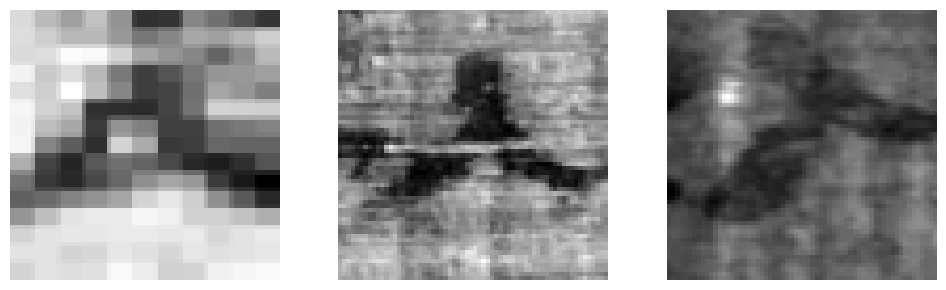


Visualizing prototypes for Letter: Delta


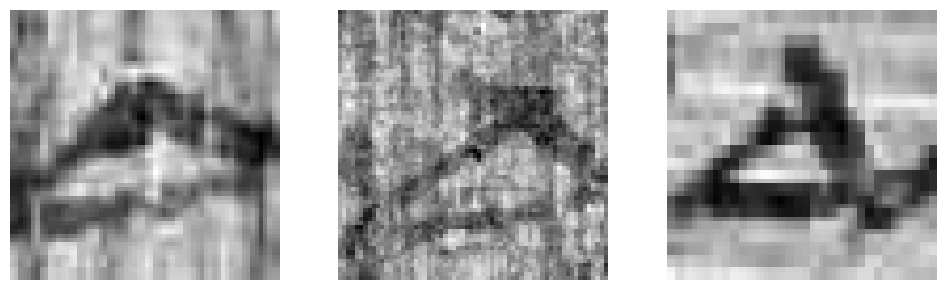


Visualizing prototypes for Letter: Rho


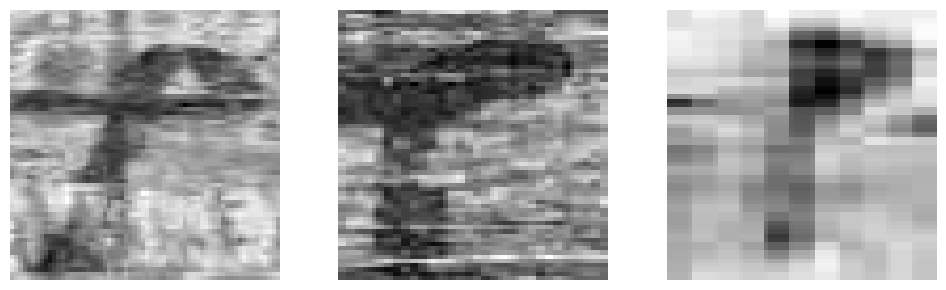


Visualizing prototypes for Letter: Theta


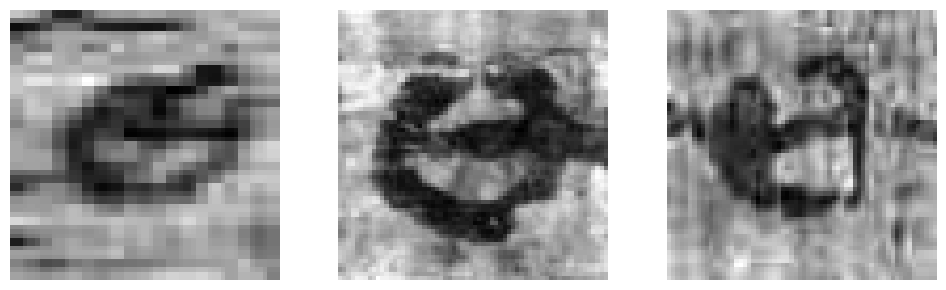


Visualizing prototypes for Letter: Xi


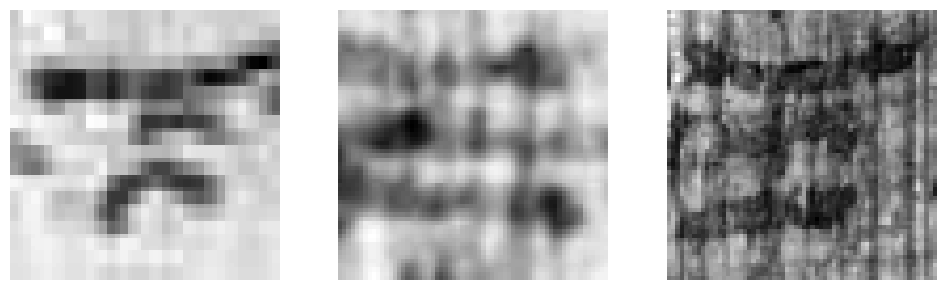

In [32]:
#@title Visualize Spectral Clustering Prototypes for Letters with 3 Clusters
from sklearn.cluster import SpectralClustering
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.spatial.distance import cdist

# Assuming embeddings and labels contain the CNN embeddings and labels before augmentation
# Assuming optimal_clusters and optimal_clusters_spectral contain the optimal k for KMeans and Spectral Clustering per letter
# Assuming train_loader_no_aug provides access to the original images
# Assuming train_indices_2d and image_data_2d are available

# Use embeddings and labels from the training set before augmentation
embeddings = train_embeddings_no_aug
labels = train_labels_no_aug

# Identify letters where optimal k is 3 for (either KMeans or) Spectral Clustering
letters_with_3_clusters = set()
#for c, k in optimal_clusters.items():
#    if k == 3:
#        letters_with_3_clusters.add(label_encoder.inverse_transform([c])[0])

for c, k in optimal_clusters_spectral.items():
     if k == 3:
        letters_with_3_clusters.add(label_encoder.inverse_transform([c])[0])

letters_with_3_clusters = sorted(list(letters_with_3_clusters))

if not letters_with_3_clusters:
    print("No letters found with an optimal number of 3 clusters based on KMeans or Spectral Clustering.")

for letter in letters_with_3_clusters:
    print(f"\nVisualizing prototypes for Letter: {letter}")

    # Get the index for this letter
    letter_idx = label_encoder.transform([letter])[0]

    # Subset embeddings and labels for this letter from the TRAINING SET
    class_indices_in_train_set = np.where(labels == letter_idx)[0]
    class_embeddings = embeddings[class_indices_in_train_set]
    class_true_labels = labels[class_indices_in_train_set] # Should all be the same letter_idx

    if len(class_embeddings) < 3:
         print(f"Not enough samples for letter {letter} in the training set ({len(class_embeddings)}) to form 3 clusters.")
         continue

    # Perform Spectral Clustering with k=3 to get cluster assignments
    try:
        spectral = SpectralClustering(n_clusters=3,
                                      assign_labels='discretize', # or 'kmeans'
                                      random_state=42,
                                      affinity='nearest_neighbors',
                                      n_neighbors=min(10, len(class_embeddings) - 1)) # Number of neighbors

        clusters = spectral.fit_predict(class_embeddings)

        # Check if 3 distinct clusters were found
        if len(np.unique(clusters)) < 3:
             print(f"Spectral Clustering found less than 3 clusters for letter {letter}. Skipping prototype visualization.")
             continue

        plt.figure(figsize=(10, 3))
        #plt.suptitle(f"Prototypes for Letter: {letter} (Spectral Clustering with k=3)", fontsize=14)

        for cluster_id in range(3):
            # Find the medoid (sample closest to the centroid) for each cluster
            cluster_samples_indices_in_subset = np.where(clusters == cluster_id)[0]
            if len(cluster_samples_indices_in_subset) > 0:
                cluster_samples_embeddings = class_embeddings[cluster_samples_indices_in_subset]
                centroid = cluster_samples_embeddings.mean(axis=0)
                distances_to_centroid = cdist(cluster_samples_embeddings, centroid.reshape(1, -1)).squeeze()
                medoid_index_in_subset = cluster_samples_indices_in_subset[np.argmin(distances_to_centroid)]

                # The index within the training set corresponding to this medoid sample is:
                idx_in_train_set = class_indices_in_train_set[medoid_index_in_subset]

                # Get the original image from the loader using the index within the train subset
                try:
                    img, _ = train_loader_no_aug.dataset[idx_in_train_set]

                    if isinstance(img, torch.Tensor):
                        img = img.squeeze().cpu().numpy()

                    plt.subplot(1, 3, cluster_id + 1)
                    plt.imshow(img, cmap="gray")
                    #plt.title(f"Cluster {cluster_id}")
                    plt.axis("off")
                except IndexError:
                     print(f"Error retrieving image for letter {letter}, cluster {cluster_id} at training set index {idx_in_train_set}. Index might be out of bounds for the dataset.")
                     continue
            else:
                print(f"Warning: Cluster {cluster_id} for letter {letter} is empty. Skipping prototype visualization.")


        #plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error performing Spectral Clustering for letter {letter}: {e}")
        continue


Visualizing prototypes for Letter: Alpha (Optimal k = 3)


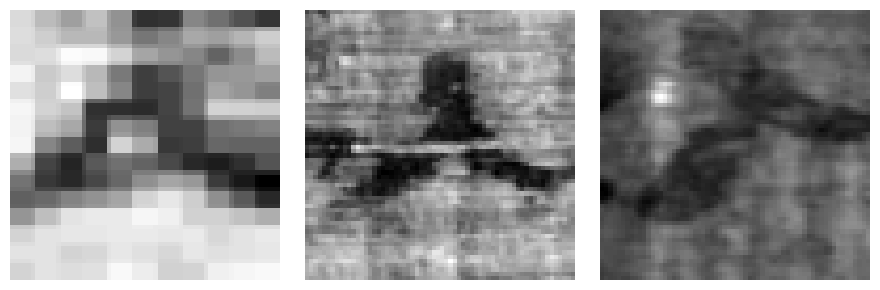


Visualizing prototypes for Letter: Beta (Optimal k = 2)


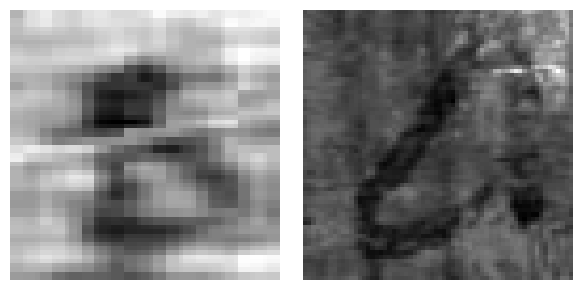


Visualizing prototypes for Letter: Chi (Optimal k = 2)


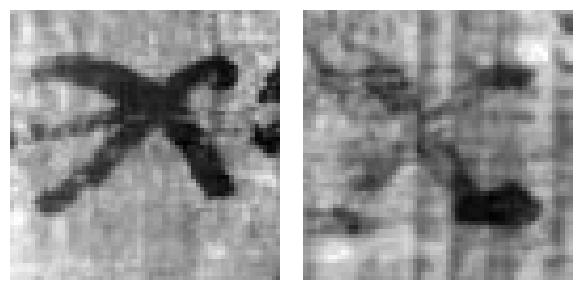


Visualizing prototypes for Letter: Delta (Optimal k = 3)


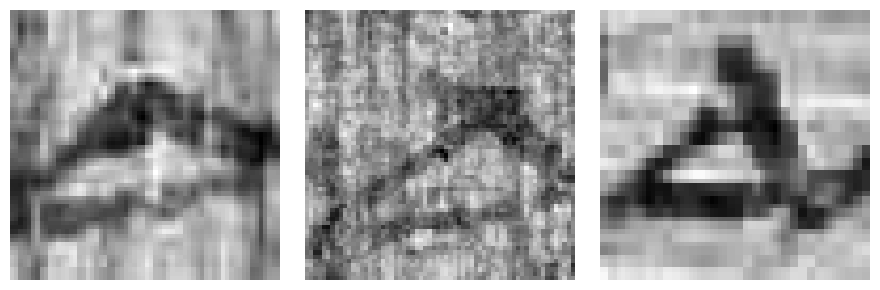


Visualizing prototypes for Letter: Epsilon (Optimal k = 2)


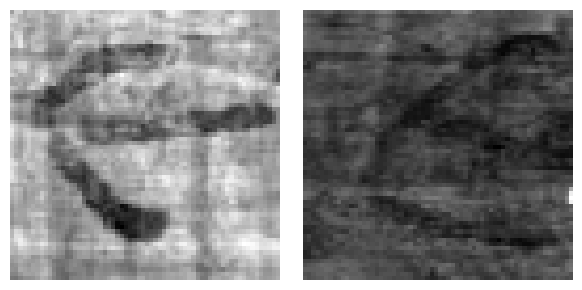


Visualizing prototypes for Letter: Eta (Optimal k = 2)


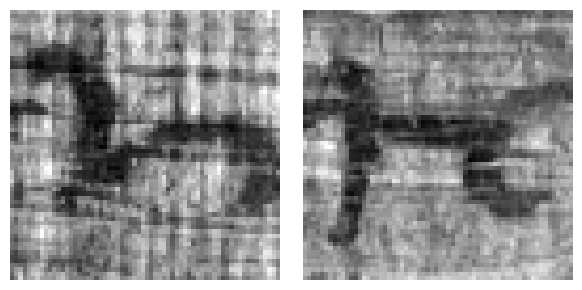


Visualizing prototypes for Letter: Gamma (Optimal k = 2)


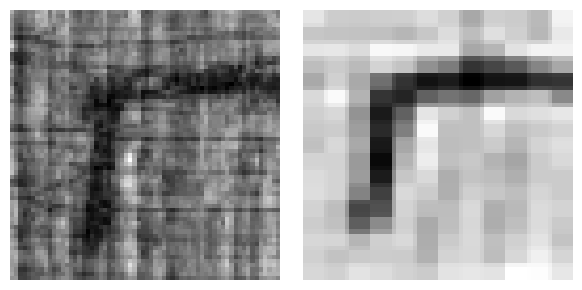


Visualizing prototypes for Letter: Iota (Optimal k = 2)


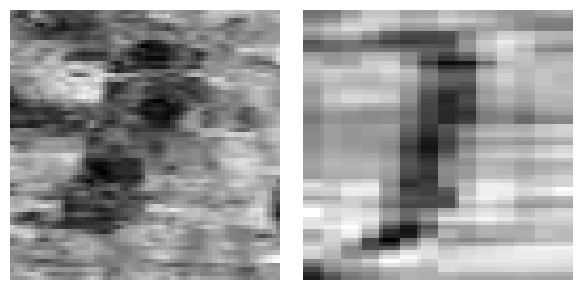


Visualizing prototypes for Letter: Kappa (Optimal k = 2)


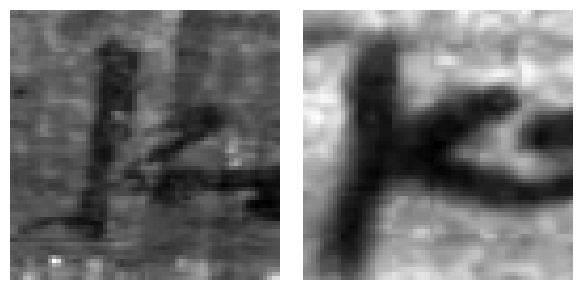


Visualizing prototypes for Letter: Lambda (Optimal k = 2)


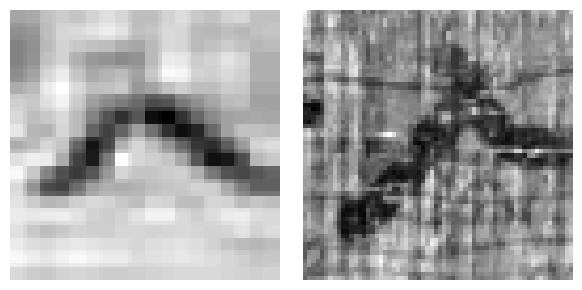


Visualizing prototypes for Letter: Mu (Optimal k = 2)


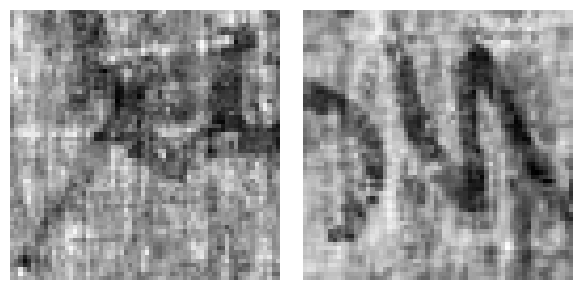


Visualizing prototypes for Letter: Nu (Optimal k = 2)


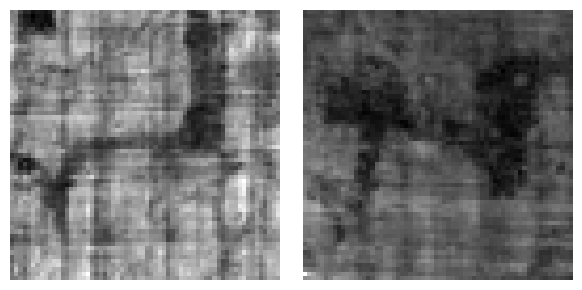


Visualizing prototypes for Letter: Omega (Optimal k = 2)


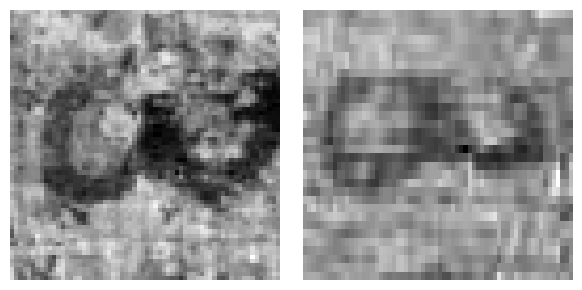


Visualizing prototypes for Letter: Omicron (Optimal k = 2)


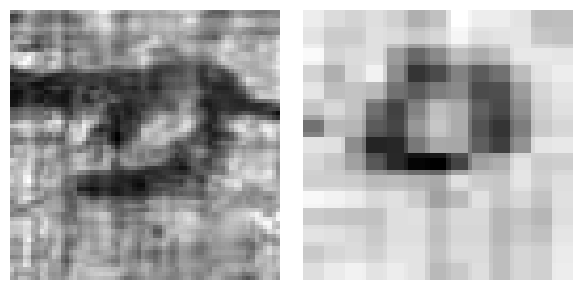


Visualizing prototypes for Letter: Phi (Optimal k = 2)


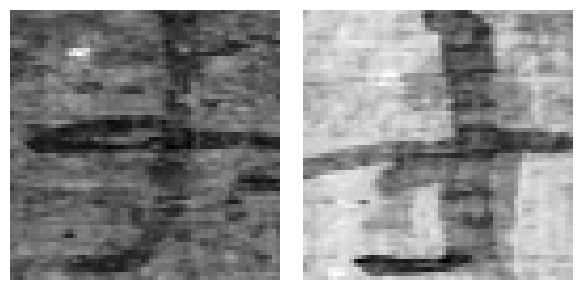


Visualizing prototypes for Letter: Pi (Optimal k = 2)


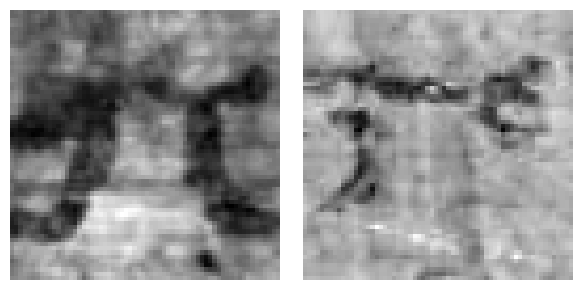


Visualizing prototypes for Letter: Psi (Optimal k = 4)


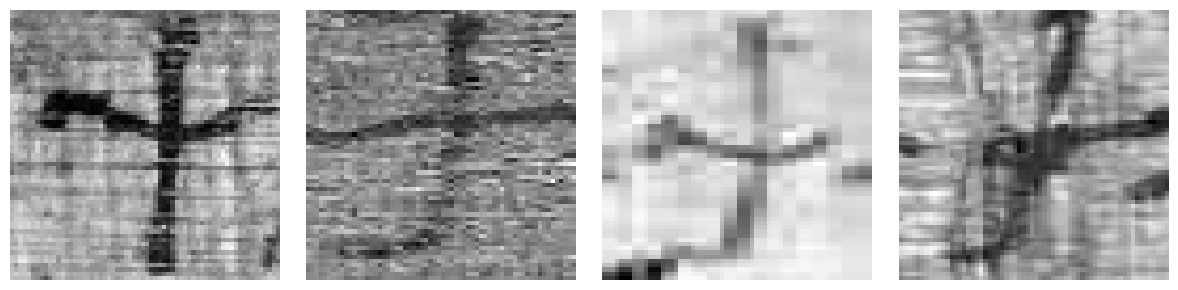


Visualizing prototypes for Letter: Rho (Optimal k = 3)


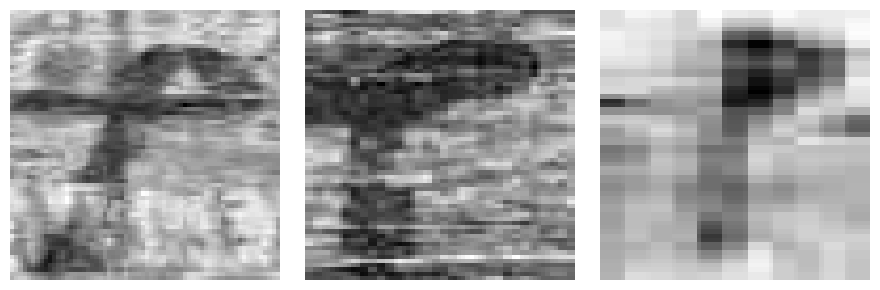


Visualizing prototypes for Letter: Sigma (Optimal k = 2)


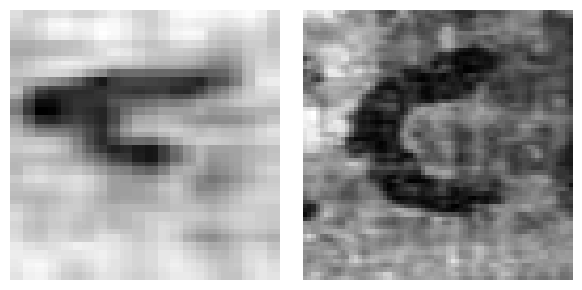


Visualizing prototypes for Letter: Tau (Optimal k = 2)


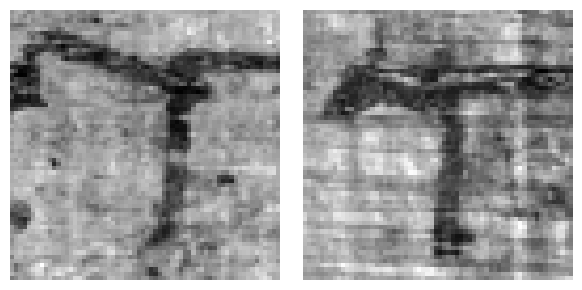


Visualizing prototypes for Letter: Theta (Optimal k = 3)


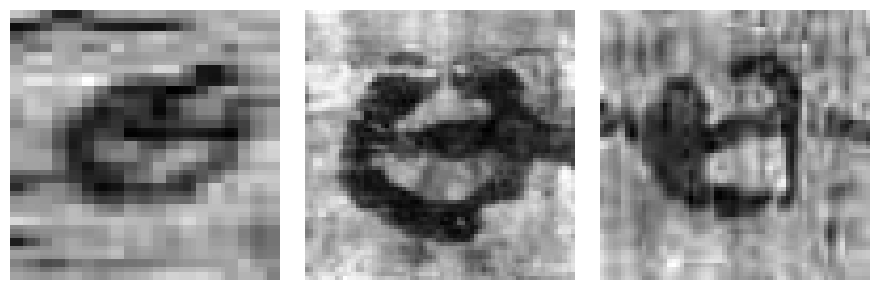


Visualizing prototypes for Letter: Upsilon (Optimal k = 2)


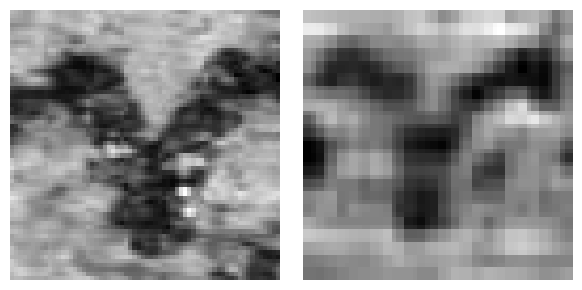


Visualizing prototypes for Letter: Xi (Optimal k = 3)


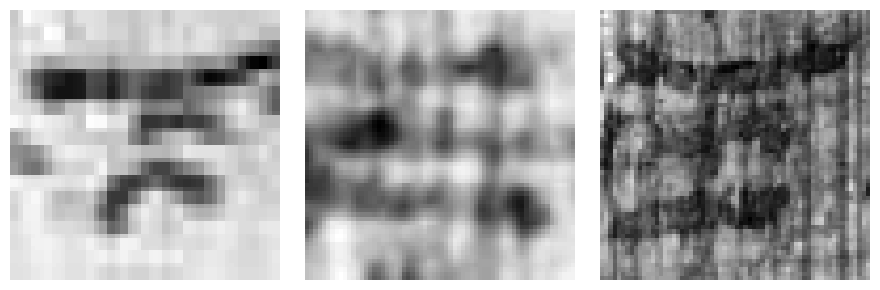


Visualizing prototypes for Letter: Zeta (Optimal k = 2)


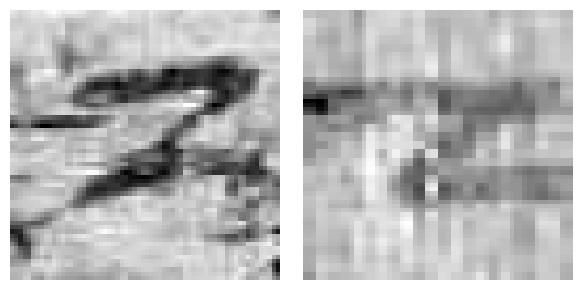

In [33]:
#@title Visualize Spectral Clustering Prototypes for Letters with Any Number of Clusters
from sklearn.cluster import SpectralClustering
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.spatial.distance import cdist

# Assuming embeddings and labels contain the CNN embeddings and labels before augmentation
# Assuming optimal_clusters_spectral contain the optimal k for Spectral Clustering per letter
# Assuming train_loader_no_aug provides access to the original images
# Assuming train_indices_2d and image_data_2d are available

# Use embeddings and labels from the training set before augmentation
embeddings = train_embeddings_no_aug
labels = train_labels_no_aug

# Iterate through all letters and their optimal number of clusters
for c, optimal_k in optimal_clusters_spectral.items():
    letter = label_encoder.inverse_transform([c])[0]
    print(f"\nVisualizing prototypes for Letter: {letter} (Optimal k = {optimal_k})")

    # Subset embeddings and labels for this letter from the TRAINING SET
    class_indices_in_train_set = np.where(labels == c)[0]
    class_embeddings = embeddings[class_indices_in_train_set]
    class_true_labels = labels[class_indices_in_train_set] # Should all be the same letter_idx

    if len(class_embeddings) < optimal_k:
         print(f"Not enough samples for letter {letter} in the training set ({len(class_embeddings)}) to form {optimal_k} clusters.")
         continue

    # Perform Spectral Clustering with the optimal k
    try:
        # Adjust n_neighbors for Spectral Clustering based on the number of samples
        n_neighbors_sc = min(10, len(class_embeddings) - 1)
        if n_neighbors_sc < 1:
             print(f"Not enough samples to determine nearest neighbors for letter {letter}. Skipping visualization.")
             continue

        spectral = SpectralClustering(n_clusters=optimal_k,
                                      assign_labels='discretize', # or 'kmeans'
                                      random_state=42,
                                      affinity='nearest_neighbors',
                                      n_neighbors=n_neighbors_sc)

        clusters = spectral.fit_predict(class_embeddings)

        # Check if the optimal_k distinct clusters were found
        if len(np.unique(clusters)) < optimal_k:
             print(f"Spectral Clustering found less than {optimal_k} distinct clusters for letter {letter}. Skipping prototype visualization.")
             continue

        plt.figure(figsize=(optimal_k * 3, 3)) # Adjust figure size based on number of clusters
        #plt.suptitle(f"Prototypes for Letter: {letter} (Spectral Clustering with k={optimal_k})", fontsize=14)

        for cluster_id in range(optimal_k):
            # Find the medoid (sample closest to the centroid) for each cluster
            cluster_samples_indices_in_subset = np.where(clusters == cluster_id)[0]
            if len(cluster_samples_indices_in_subset) > 0:
                cluster_samples_embeddings = class_embeddings[cluster_samples_indices_in_subset]
                centroid = cluster_samples_embeddings.mean(axis=0)
                distances_to_centroid = cdist(cluster_samples_embeddings, centroid.reshape(1, -1)).squeeze()
                medoid_index_in_subset = cluster_samples_indices_in_subset[np.argmin(distances_to_centroid)]

                # The index within the training set corresponding to this medoid sample is:
                idx_in_train_set = class_indices_in_train_set[medoid_index_in_subset]

                # Get the original image from the loader using the index within the train subset
                try:
                    img, _ = train_loader_no_aug.dataset[idx_in_train_set]

                    if isinstance(img, torch.Tensor):
                        img = img.squeeze().cpu().numpy()

                    plt.subplot(1, optimal_k, cluster_id + 1)
                    plt.imshow(img, cmap="gray")
                    #plt.title(f"Cluster {cluster_id}")
                    plt.axis("off")
                except IndexError:
                     print(f"Error retrieving image for letter {letter}, cluster {cluster_id} at training set index {idx_in_train_set}. Index might be out of bounds for the dataset.")
                     continue
            else:
                print(f"Warning: Cluster {cluster_id} for letter {letter} is empty. Skipping prototype visualization.")

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Error performing Spectral Clustering for letter {letter} with k={optimal_k}: {e}")
        continue